# Concrete Strength Prediction Project

In this project, we analyze a concrete dataset to understand how different components like cement, water, and age affect the strength of concrete. The goal is to explore the data and later build a machine learning model to predict concrete strength.

## Step 1: Load and Inspect the Dataset

In this step, we load the dataset into Python using pandas and display the first few rows. This helps us understand the structure of the data and the available features.

In [ ]:
import pandas as pd

df = pd.read_excel("uci_concrete_data.xlsx")
df.head()

SyntaxError: invalid syntax (3323010859.py, line 3)

## Step 2: Dataset Overview

- Checked dataset size, structure, and quality  
- Features: cement, water, aggregates, age  
- Target: concrete compressive strength  
- Missing values present  

In [ ]:
# check dataset size (rows, columns)
df.shape

(1080, 9)

In [ ]:
# check data types and basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1048 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1050 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1042 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1051 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1080 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1080 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1080 non-null   float64
 7   Age (day)                                              1080 non-null   float64
 8   Concrete compressive strength(MPa, megapascals)        1080 

In [ ]:
# check missing values
df.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                32
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    30
Fly Ash (component 3)(kg in a m^3 mixture)               38
Water  (component 4)(kg in a m^3 mixture)                29
Superplasticizer (component 5)(kg in a m^3 mixture)       0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0
Fine Aggregate (component 7)(kg in a m^3 mixture)         0
Age (day)                                                 0
Concrete compressive strength(MPa, megapascals)           0
dtype: int64

## Step 3: Data Cleaning

- Missing values identified in input features  
- Removed missing data using dropna()  
- Dataset cleaned and ready for modeling  

In [ ]:
# remove missing values
df = df.dropna()

In [ ]:
# verify again
df.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

In [ ]:
# check new dataset size
df.shape

(1030, 9)

## Step 4: Data Visualization

- Visualized target variable distribution  
- Observed how values are spread  

In [ ]:
df.columns = [
    "cement",
    "slag",
    "fly_ash",
    "water",
    "superplasticizer",
    "coarse_agg",
    "fine_agg",
    "age",
    "strength"
]

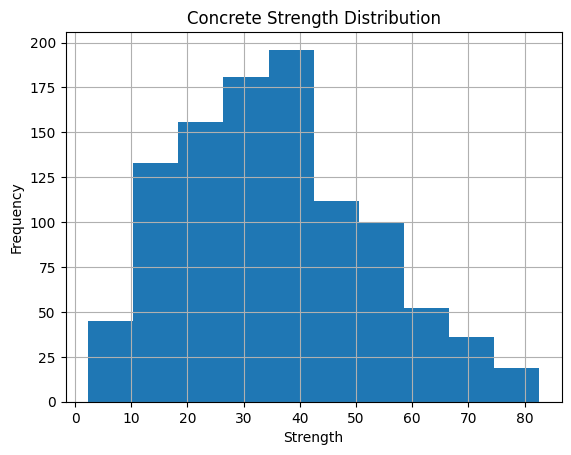

In [ ]:
import matplotlib.pyplot as plt
df["strength"].hist()
plt.title("Concrete Strength Distribution")
plt.xlabel("Strength")
plt.ylabel("Frequency")

plt.grid(True)   # 👈 ADD THIS LINE

plt.show()

- Strength values are mostly concentrated in mid range  
- Distribution is slightly spread across values  

## Step 5: Feature Relationship Analysis

- Analyzed relationship between input features and strength  
- Used scatter plot to observe pattern  

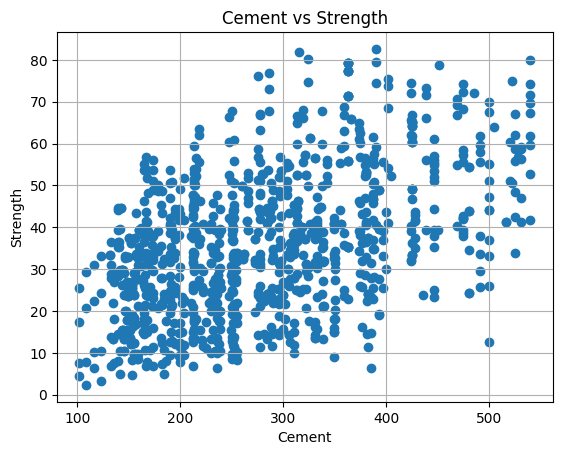

In [ ]:
plt.scatter(df["cement"], df["strength"])
plt.xlabel("Cement")
plt.ylabel("Strength")
plt.title("Cement vs Strength")
plt.grid(True)
plt.show()

- Strength generally increases with increase in cement  
- Positive relationship observed between cement and strength  

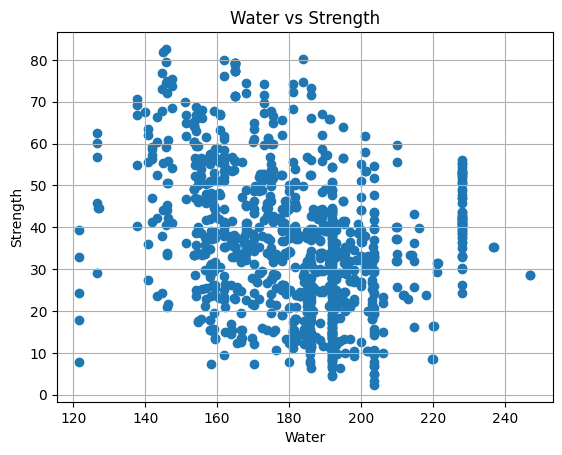

In [ ]:
plt.scatter(df["water"], df["strength"])
plt.xlabel("Water")
plt.ylabel("Strength")
plt.title("Water vs Strength")
plt.grid(True)
plt.show()

- Strength decreases as water content increases  
- Negative relationship observed between water and strength  

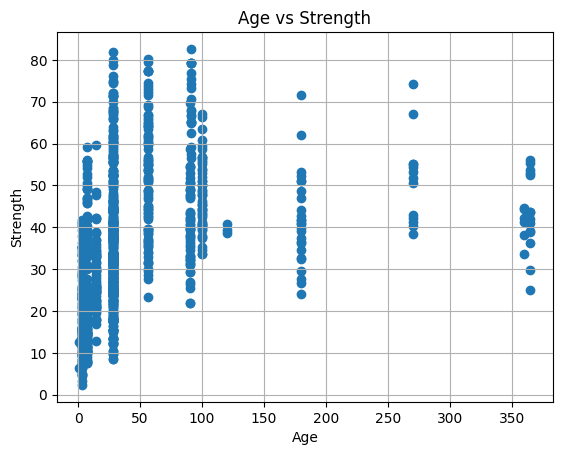

In [ ]:
plt.scatter(df["age"], df["strength"])
plt.xlabel("Age")
plt.ylabel("Strength")
plt.title("Age vs Strength")
plt.grid(True)
plt.show()

- Strength increases as age increases  
- Positive relationship observed between age and strength  

## Step 6: Model Building and Training

- Prepared dataset for modeling  
- Split data into training and testing sets  
- Trained Random Forest model for prediction   

In [ ]:
# Select features and target
X = df.drop("strength", axis=1)
y = df["strength"]

# Split data into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Import and create model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)

# Train model
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Step 7: Model Evaluation

- Predicted values using trained model  
- Compared predictions with actual values  
- Evaluated model performance using metrics  

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 3.2144522478123965
Mean Squared Error: 21.98612495151258
R2 Score: 0.9138784834537785


### Model Performance Summary

- R² Score is above 0.9, indicating strong predictive performance  
- Mean Absolute Error is low, showing accurate predictions  
- Model performs well in estimating concrete strength  

## Step 8: Conclusion

- Successfully built a machine learning model to predict concrete strength  
- Identified key relationships between features and strength  
- Random Forest model achieved high accuracy (R² ≈ 0.91)  
- Model can be used for predicting strength in practical applications  